In [1]:
import sys

sys.path.append("/home/atuin/v120bb/v120bb18/UnReflectAnything")

import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms

from PIL import Image
from utilities import panelize, rgb
from main import load_and_process_config, create_model_from_config
from dataset import from_config

# Load autoreload for development
%load_ext autoreload
%autoreload 2    

In [2]:
config = load_and_process_config("config_train.yaml")
dataset = from_config(config)["training"]

DATASET  [22:32:07] Processing 7 datasets: ['SCRREAM', 'HOUSECAT6D', 'CROMO', 'PSD', 'SCARED', 
'STEREOMIS_TRACKING', 'CHOLEC80']

DATASET  [22:32:07] Using all scenes except VAL_SCENES for SCRREAM training

DATASET  [22:32:07]   ✓ Created training dataset for SCRREAM: 3404 samples (excluding 6 val scenes)

DATASET  [22:32:07]   ✓ Created validation dataset for SCRREAM: 717 samples from 6 scenes

DATASET  [22:32:07] Using all scenes except VAL_SCENES for HOUSECAT6D training

...

DATASET  [22:32:07]   ✓ Created validation dataset for CHOLEC80: 461 samples from 1 scenes

DATASET  [22:32:07] === Dataset Creation Summary ===

DATASET  [22:32:07] Training:   16539 total samples

DATASET  [22:32:07] Validation: 4540 total samples

DATASET  [22:32:07] Test:       4540 total samples

In [6]:
from torchinfo import summary
from polar_highlighter import PolarHighlighter, get_soft_highlight_map

# ph = PolarHighlighter(
#     width=config.MODEL.RGB_ENCODER.IMAGE_SIZE,
#     height=config.MODEL.RGB_ENCODER.IMAGE_SIZE,
# ).cuda()
idataloadr = iter(torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True))
batch = next(idataloadr)
image = batch["raw"].cuda(non_blocking=True)

In [10]:
config = load_and_process_config("config_train.yaml")
from models_utils import load_best_model_by_run
model = load_best_model_by_run("crisp-bee-609").eval()
# model = create_model_from_config(config, device="cuda").eval()

INFO     [22:36:49] Found valid run to resume: /anvme/workspace/v120bb18-unreflectanything/results/crisp-bee-609

INFO     [22:36:49] Latest checkpoint: 
/anvme/workspace/v120bb18-unreflectanything/results/crisp-bee-609/models/weights_best.pt

INFO     [22:36:49] Latest epoch: 11

✓ Decoder 'diffuse': Successfully loaded all 54 state dict keys from weights/rgb_decoder.pth


MODEL    [22:36:51] Loaded pre-trained decoder weights from weights/rgb_decoder.pth

MODEL    [22:36:51] Decoder 'diffuse' frozen due to DECODER_LR=0.0

MODEL    [22:36:51] Decoder 'highlight' un-frozen due to DECODER_LR=0.0005

MODEL    [22:36:52] Model with class UnReflect_Model_TokenInpainter created with 498,003,972 parameters

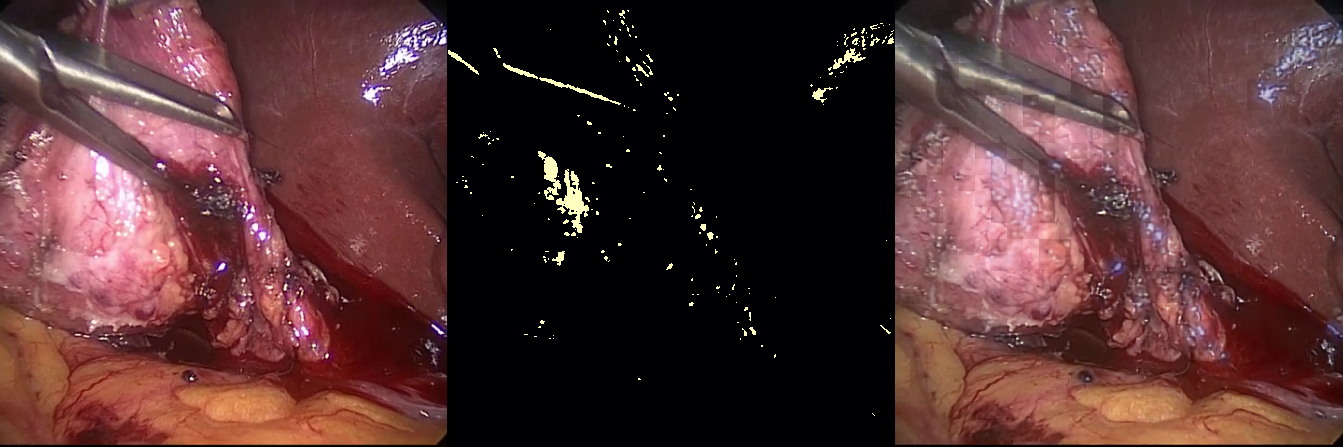

In [12]:
torch.cuda.empty_cache()
inpaintme = (image.mean(dim=1,keepdim=True) > 0.85)
# dinov3c_out = model.dinov3(image)
modelout = model({"rgb": image[0].unsqueeze(0), "inpaint_mask_override": inpaintme[0].unsqueeze(0)})
# rgb(panelize(*[rgb(h[0],resize=(224,224),as_tensor=True) for h in dinov3c_out["selected_hidden_states"]]))
rgb(
    panelize(
        rgb(image, as_tensor=True),
        rgb(inpaintme.float(), as_tensor=True),
        rgb(modelout["diffuse"], as_tensor=True),
    )
)

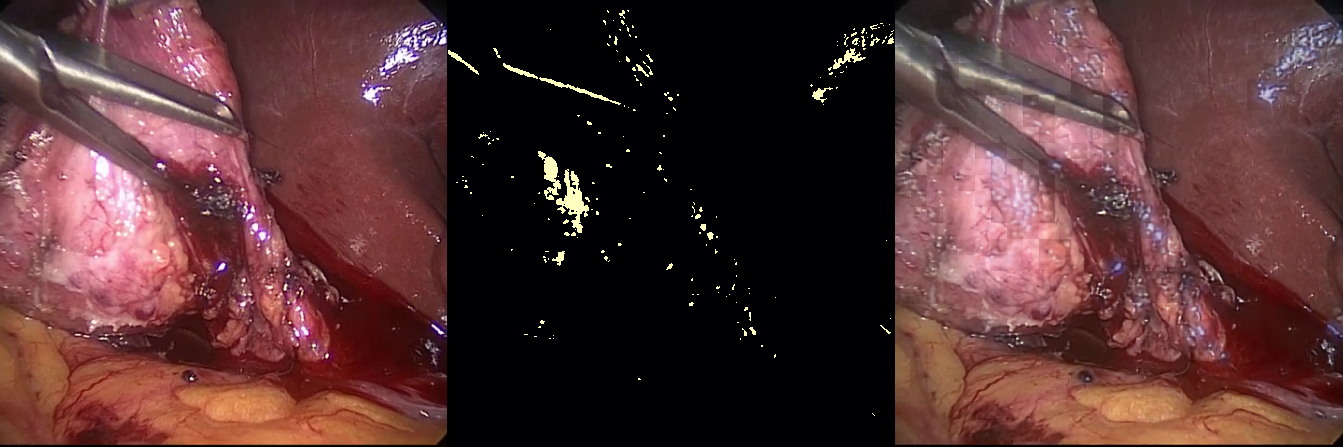

In [ ]:
torch.cuda.empty_cache()     #1 
inpaintme = (image.mean(dim=1,keepdim=True) > 0.85)
# dinov3c_out = model.dinov3(image)
modelout = model({"rgb": image[0].unsqueeze(0), "inpaint_mask_override": inpaintme[0].unsqueeze(0)})
# rgb(panelize(*[rgb(h[0],resize=(224,224),as_tensor=True) for h in dinov3c_out["selected_hidden_states"]]))
rgb(
    panelize(
        rgb(image, as_tensor=True),
        rgb(inpaintme.float(), as_tensor=True),
        rgb(modelout["diffuse"], as_tensor=True),
    )
)

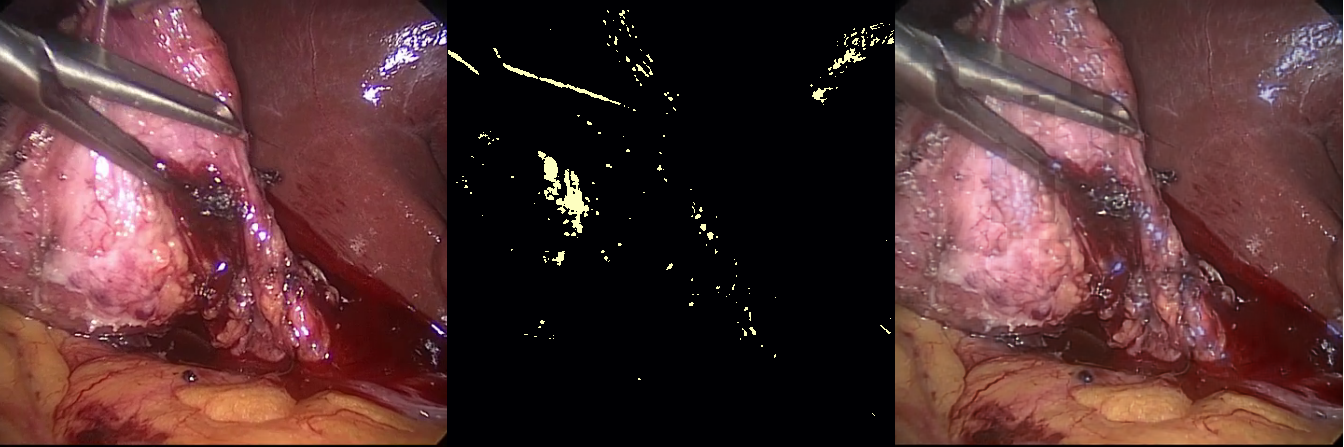

In [ ]:
torch.cuda.empty_cache()   # 5
inpaintme = (image.mean(dim=1,keepdim=True) > 0.85)
# dinov3c_out = model.dinov3(image)
modelout = model({"rgb": image[0].unsqueeze(0), "inpaint_mask_override": inpaintme[0].unsqueeze(0)})
# rgb(panelize(*[rgb(h[0],resize=(224,224),as_tensor=True) for h in dinov3c_out["selected_hidden_states"]]))
rgb(
    panelize(
        rgb(image, as_tensor=True),
        rgb(inpaintme.float(), as_tensor=True),
        rgb(modelout["diffuse"], as_tensor=True),
    )
)

In [ ]:
# Similar to DINOv3 usage
from models import DINOv3_ConvNext

convnext_config = {
    "model_name": "facebook/dinov3-convnext-large-pretrain-lvd1689m",
    "image_size": 896,
    "freeze_backbone": True,
    # "return_selected_layers": [0, 1, 2, 3],  # For DPT decoder
    "return_all_hidden_states": True,
    "return_as_feature_maps": True,
}

dinov3_convnext = DINOv3_ConvNext(convnext_config).cuda()
idataloadr = iter(torch.utils.data.DataLoader(dataset, batch_size=2, shuffle=True))
batch = next(idataloadr)
image = batch["raw"].cuda(non_blocking=True)
dinov3c_out = dinov3_convnext(image)
for k, v in dinov3c_out.items():
    if isinstance(v, torch.Tensor):
        print(k, v.shape)
    elif isinstance(v, list):
        for i, t in enumerate(v):
            if isinstance(t, torch.Tensor):
                print(f"{k}[{i}]", t.shape)

last_hidden_state torch.Size([2, 197, 1536])
all_hidden_states[0] torch.Size([2, 3, 448, 448])
all_hidden_states[1] torch.Size([2, 192, 112, 112])
all_hidden_states[2] torch.Size([2, 384, 56, 56])
all_hidden_states[3] torch.Size([2, 768, 28, 28])
all_hidden_states[4] torch.Size([2, 1536, 14, 14])
selected_hidden_states[0] torch.Size([2, 192, 112, 112])
selected_hidden_states[1] torch.Size([2, 384, 56, 56])
selected_hidden_states[2] torch.Size([2, 768, 28, 28])
selected_hidden_states[3] torch.Size([2, 1536, 14, 14])


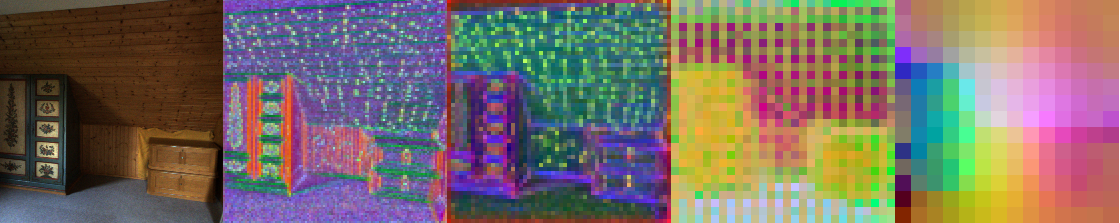

In [ ]:
rgb(
    panelize(
        *[
            rgb(h[0], resize=(224, 224), as_tensor=True)
            for h in dinov3c_out["all_hidden_states"]
        ]
    )
)


In [74]:
config = load_and_process_config("config_train.yaml")
model = create_model_from_config(config, device="cuda").eval()

MODEL    [17:48:55] Decoder 'diffuse' un-frozen due to DECODER_LR=None

MODEL    [17:48:55] Decoder 'highlight' un-frozen due to DECODER_LR=None

MODEL    [17:48:55] Model with class UnReflect_Model created with 313,926,852 parameters

In [77]:
model_out = model({"rgb": image})

In [ ]:
# model_out = dinov3_convnext(image)
for k, v in model_out.items():
    if isinstance(v, torch.Tensor):
        print(k, v.shape)
    elif isinstance(v, list):
        for i, t in enumerate(v):
            if isinstance(t, torch.Tensor):
                print(f"{k}[{i}]", t.shape)

diffuse torch.Size([2, 3, 448, 448])
highlight torch.Size([2, 1, 448, 448])


In [ ]:
model

In [7]:
config = load_and_process_config("config_train.yaml")
config.MODEL.MODEL_CLASS = "UnReflect_Model_FiLMConditioned"
model = create_model_from_config(config, device="cuda").eval()
idataloadr = iter(torch.utils.data.DataLoader(dataset, batch_size=2, shuffle=True))
batch = next(idataloadr)
image = batch["raw"].cuda(non_blocking=True)
out = ph(rgb=image, intensity=2, surface_roughness=10)

soft_highlight_map = get_soft_highlight_map(image, 0.95)
soft_highlight_map = torch.logical_not(
    torch.nn.functional.max_pool2d(
        soft_highlight_map,
        kernel_size=25,
        stride=1,
        padding=25 // 2,
    )
    > 0
).int()
real_and_virtual_highlights = (out["highlight"] + soft_highlight_map).clamp(0, 1)

model_out = model({"rgb": image})
rgb_in = model.dinov3.preprocess_image(image)
rgb_tokens = model.dinov3(rgb_in)["selected_hidden_states"]
print("Feature maps shapes")
for i in range(len(rgb_tokens)):
    print(tuple(rgb_tokens[i].reshape(2, 28, 28, 1024).shape))
print("Diffuse out: ", model_out["diffuse"].shape)
print("Mask pyramid: ", model_out["mask_pyr"][0].shape)
print("Highlight out: ", model_out["highlight"].shape)
summary(model)

rgb(
    panelize(
        rgb(out["rgb_highlighted"][0], as_tensor=True),
        rgb(real_and_virtual_highlights, colormap="gray", as_tensor=True),
        rgb(
            soft_highlight_map * out["rgb_highlighted"], colormap="gray", as_tensor=True
        ),
        rgb(
            model_out["mask_pyr"][0][0, 0],
            colormap="gray",
            as_tensor=True,
            resize=(448, 448),
        ),
    )
)

MODEL    [17:02:57] Loaded pre-trained decoder weights from weights/rgb_decoder.pth

MODEL    [17:02:57] Decoder 'diffuse' frozen due to DECODER_LR=0.0

MODEL    [17:02:57] Decoder 'highlight' un-frozen due to DECODER_LR=None

MODEL    [17:02:57] Model with class UnReflect_Model_FiLMConditioned created with 421,372,932 parameters

Feature maps shapes
(2, 28, 28, 1024)
(2, 28, 28, 1024)
(2, 28, 28, 1024)
(2, 28, 28, 1024)
Diffuse out:  torch.Size([2, 3, 448, 448])


KeyError: 'mask_pyr'

In [13]:
dinov3_convnext(image)

ValueError: not enough values to unpack (expected 4, got 3)

MODEL    [22:04:45] Model with class UnReflect_Model_TokenInpainter created with 508,292,932 parameters

highlight torch.Size([1, 1, 448, 448])
patch_mask torch.Size([1, 784])
diffuse torch.Size([1, 3, 448, 448])
tokens_teacher 4
tokens_completed 4


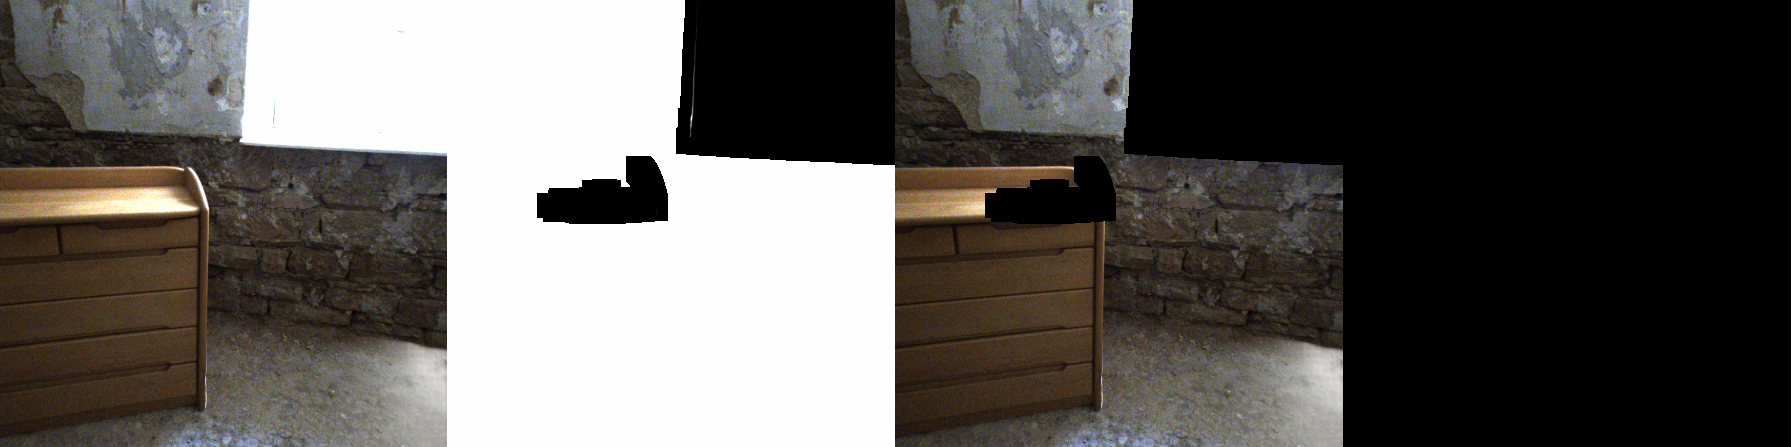

In [5]:
config = load_and_process_config("config_train.yaml")
config.MODEL.MODEL_CLASS = "UnReflect_Model_TokenInpainter"
config.MODEL.DECODERS.diffuse.USE_FILM = False
model = create_model_from_config(config, device="cuda").eval()
idataloadr = iter(torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True))
batch = next(idataloadr)
image = batch["raw"].cuda(non_blocking=True)
model_out = model({"rgb": image})
for k, v in model_out.items():
    print(k, v.shape if hasattr(v, "shape") else len(v))
from torchinfo import summary

summary(model)
rgb(
    panelize(
        rgb(out["rgb_highlighted"], as_tensor=True),
        rgb(real_and_virtual_highlights, colormap="gray", as_tensor=True),
        rgb(
            soft_highlight_map * out["rgb_highlighted"], colormap="gray", as_tensor=True
        ),
        rgb(
            model_out["patch_mask"].int().reshape(1, 28, 28),
            colormap="gray",
            as_tensor=True,
            resize=(448, 448),
        ),
    )
)

In [25]:
print(comp.shape)
print(model_out["patch_mask"].reshape(1, 28, 28).unsqueeze(0).shape)

torch.Size([1, 3, 448, 448])
torch.Size([1, 1, 28, 28])


In [ ]:
model_out["patch_mask"].reshape(1, 28, 28).unique()
model_out["patch_mask"][0, 50:60] = 0

In [32]:
model_out["patch_mask"].unique()

tensor([False,  True], device='cuda:0')

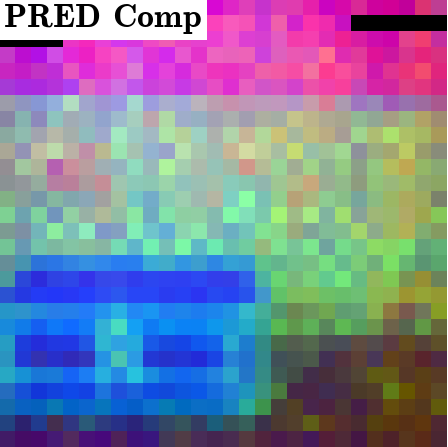

In [ ]:
def make_black_image():
    return torch.zeros(3, 448, 448)


comp = rgb(
    model_out["tokens_teacher"][-1]
    .reshape(-1, 28, 28, 1024)
    .permute(0, 3, 1, 2)
    .detach()
    * model_out["patch_mask"].reshape(1, 28, 28).int(),
    as_tensor=True,
    resize=(448, 448),
    blackout=True,
    interpolation="nearest",
).unsqueeze(0)
pred_decomposition = {"comp": comp}
comp_name = "comp"
rgb(
    pred_decomposition[comp_name][0][:3].detach()
    if comp_name in pred_decomposition
    else make_black_image(),
    # as_tensor=True,
    resize=(448, 448),
    colormap="gray",
    # border={"color": "#ffffff   ", "thickness": 1 if comp_name not in pred_decomposition else 0} ,
    label={
        "position": "top-left",
        "height": 40,
        "margin": 1 if comp_name not in pred_decomposition else 0,
        "text": f"PRED {comp_name.capitalize()}"
        if comp_name in pred_decomposition
        else "NA",
    },
)

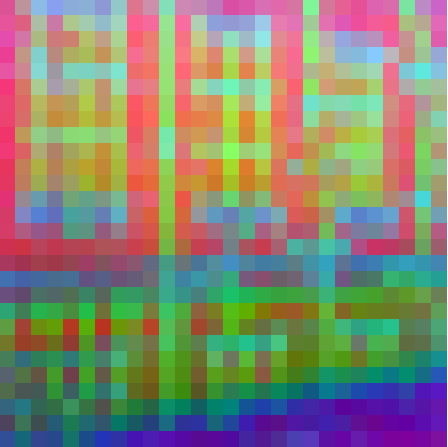

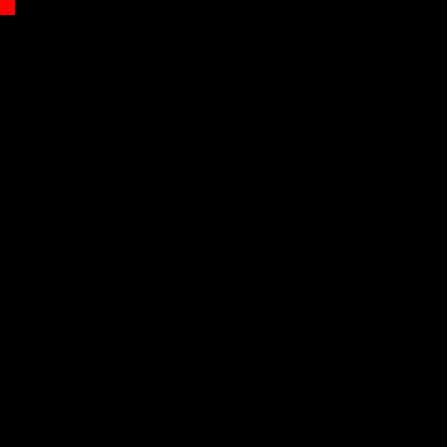

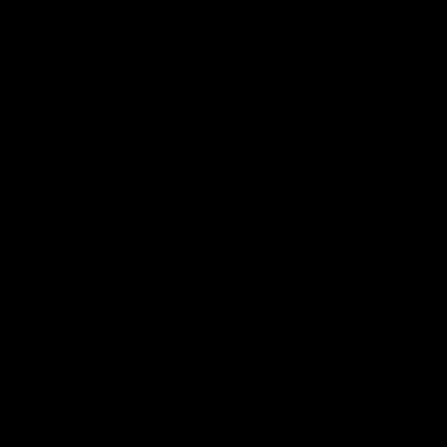

(None,)

In [ ]:
rgb(
    model_out["tokens_teacher"][-1].reshape(1, 28, 28, 1024).permute(0, 3, 1, 2),
    scale=16,
)
rgb(
    model_out["tokens_completed"][-1]
    .reshape(1, 28, 28, 1024)
    .permute(0, 3, 1, 2)
    .detach(),
    scale=16,
)
(rgb(model_out["patch_mask"].int().reshape(1, 28, 28)[0], colormap="gray", scale=16),)
